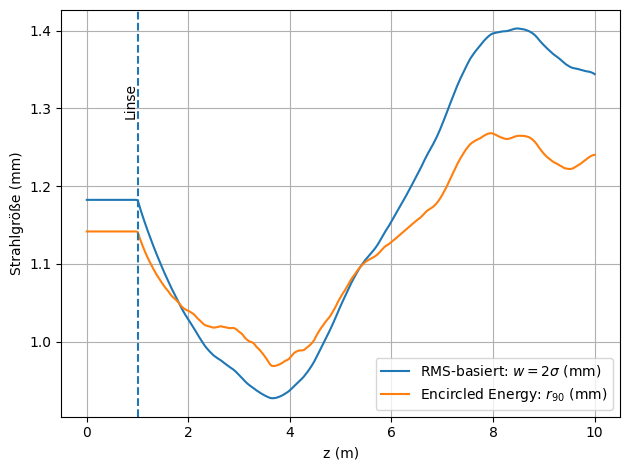

Focus (min w_rms) at z = 3.64548 m, w0 = 927.441 um
Focus (min r90) at z = 3.67893 m, r90 = 968.791 um


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# ASM propagation
# -----------------------------
def asm_propagate(U, dx, dy, wavelength, z):
    ny, nx = U.shape
    k = 2 * np.pi / wavelength

    fx = np.fft.fftfreq(nx, d=dx)
    fy = np.fft.fftfreq(ny, d=dy)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2 * np.pi * FX
    ky = 2 * np.pi * FY
    kz2 = k**2 - kx**2 - ky**2

    kz = np.sqrt(np.maximum(0.0, kz2))     # drop evanescent
    H = np.exp(1j * z * kz)

    return np.fft.ifft2(np.fft.fft2(U) * H)

# -----------------------------
# Thin lens
# -----------------------------
def apply_thin_lens(U, x, y, wavelength, f):
    k = 2 * np.pi / wavelength
    X, Y = np.meshgrid(x, y)
    return U * np.exp(-1j * k * (X**2 + Y**2) / (2 * f))

# -----------------------------
# RMS (2nd moment) beam size
# -----------------------------
def rms_moments(I, x, y):
    """
    Returns (sigma_x, sigma_y, sigma_eq) where sigma_eq = sqrt((sx^2+sy^2)/2).
    """
    I = np.maximum(I, 0.0)
    P = I.sum()
    if P <= 0:
        return np.nan, np.nan, np.nan

    X, Y = np.meshgrid(x, y)
    x0 = (I * X).sum() / P
    y0 = (I * Y).sum() / P

    sx2 = (I * (X - x0)**2).sum() / P
    sy2 = (I * (Y - y0)**2).sum() / P

    sx = np.sqrt(sx2)
    sy = np.sqrt(sy2)
    seq = np.sqrt((sx2 + sy2) / 2.0)
    return sx, sy, seq

# -----------------------------
# Encircled energy radius (e.g. 90%)
# -----------------------------
def encircled_energy_radius(I, x, y, frac=0.90):
    """
    Radius r such that sum(I within r) = frac * total.
    Uses center of mass as beam center.
    """
    I = np.maximum(I, 0.0)
    P = I.sum()
    if P <= 0:
        return np.nan

    X, Y = np.meshgrid(x, y)
    x0 = (I * X).sum() / P
    y0 = (I * Y).sum() / P

    R = np.sqrt((X - x0)**2 + (Y - y0)**2)

    r_flat = R.ravel()
    i_flat = I.ravel()
    idx = np.argsort(r_flat)

    r_sorted = r_flat[idx]
    i_sorted = i_flat[idx]

    c = np.cumsum(i_sorted)
    target = frac * c[-1]
    j = np.searchsorted(c, target)
    j = np.clip(j, 0, len(r_sorted) - 1)
    return r_sorted[j]

# -----------------------------
# Simulation: w(z) by RMS and r90 by energy
# -----------------------------
def simulate_sizes(U0, dx, dy, wavelength, z_list, z_lens, f, energy_frac=0.90):
    ny, nx = U0.shape
    x = (np.arange(nx) - nx//2) * dx
    y = (np.arange(ny) - ny//2) * dy

    # field at lens plane once
    U_lens = asm_propagate(U0, dx, dy, wavelength, z_lens)
    U_after = apply_thin_lens(U_lens, x, y, wavelength, f)

    # outputs
    sigma_eq = np.zeros_like(z_list, dtype=float)
    w_rms = np.zeros_like(z_list, dtype=float)   # w = 2*sigma_eq  (D4σ radius-like)
    r90 = np.zeros_like(z_list, dtype=float)

    for i, z in enumerate(z_list):
        if z < z_lens:
            Uz = asm_propagate(U0, dx, dy, wavelength, z)
        else:
            Uz = asm_propagate(U_after, dx, dy, wavelength, z - z_lens)

        I = np.abs(Uz)**2

        sx, sy, seq = rms_moments(I, x, y)
        sigma_eq[i] = seq
        w_rms[i] = 2.0 * seq

        r90[i] = encircled_energy_radius(I, x, y, frac=energy_frac)

    return x, y, w_rms, sigma_eq, r90

# -----------------------------
# Example run
# -----------------------------
if __name__ == "__main__":
    # Parameters
    wavelength = 800e-9
    f = 5.0
    z_lens = 1.0

    # Grid
    nx = ny = 1024
    dx = dy = 2e-6

    x = (np.arange(nx) - nx//2) * dx
    y = (np.arange(ny) - ny//2) * dy
    X, Y = np.meshgrid(x, y)

    # Flat-top-like input (super-Gaussian)
    w_in = 4.5e-3   # adjust to your beam
    m = 20
    U0 = np.exp(-((X**2 + Y**2) / w_in**2) ** m)

    # z scan
    z_list = np.linspace(0.0, 10.0, 300)

    # simulate
    x, y, w_rms, sigma_eq, r90 = simulate_sizes(
        U0, dx, dy, wavelength, z_list, z_lens, f, energy_frac=0.90
    )

    # Plot
    plt.figure()
    plt.plot(z_list, w_rms * 1e3, label=r"RMS-basiert: $w=2\sigma$ (mm)")
    plt.plot(z_list, r90 * 1e3, label=r"Encircled Energy: $r_{90}$ (mm)")

    plt.axvline(z_lens, linestyle="--")
    plt.text(z_lens, np.nanmax(w_rms)*1e3*0.95, "Linse", rotation=90, va="top", ha="right")

    plt.xlabel("z (m)")
    plt.ylabel("Strahlgröße (mm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print focus estimates
    mask = z_list >= z_lens
    idx_focus_rms = np.where(mask)[0][np.argmin(w_rms[mask])]
    idx_focus_r90 = np.where(mask)[0][np.argmin(r90[mask])]

    print(f"Focus (min w_rms) at z = {z_list[idx_focus_rms]:.6g} m, w0 = {w_rms[idx_focus_rms]*1e6:.3f} um")
    print(f"Focus (min r90) at z = {z_list[idx_focus_r90]:.6g} m, r90 = {r90[idx_focus_r90]*1e6:.3f} um")


In [1]:
pip install scipy


   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ------ --------------------------------- 6.8/39.4 MB 34.3 MB/s eta 0:00:01
   ----------------------- ---------------- 23.1/39.4 MB 57.6 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.4 MB 66.2 MB/s eta 0:00:01
   ---------------------------------------- 39.4/39.4 MB 62.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
